In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("train_data.csv")

df.head()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


In [8]:
df.columns=[
"Date",
"3M",
"6M",
"9M",
"1Y",
"2Y",
"5Y",
"10Y",
"20Y",
"30Y"
]

df.head()

,Date,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


In [9]:
df.shape

(1976, 10)

Dataset contains approximately 1976 observations of yield curves across 9 maturities.

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1976 non-null   datetime64[ns]
 1   3M      1976 non-null   float64       
 2   6M      1976 non-null   float64       
 3   9M      1976 non-null   float64       
 4   1Y      1976 non-null   float64       
 5   2Y      1976 non-null   float64       
 6   5Y      1976 non-null   float64       
 7   10Y     1976 non-null   float64       
 8   20Y     1976 non-null   float64       
 9   30Y     1976 non-null   float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 154.5 KB


In [11]:
df.describe()

,Date,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
count,1976,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000
mean,2020-05-05 23:02:25.748987904,0.016699,0.017885,0.018529,0.019174,0.018063,0.018109,0.020226,0.022823,0.022619
min,2016-05-19 00:00:00,0.000486,0.000878,0.001054,0.001227,0.001417,0.002786,0.004451,0.008394,0.006921
25%,2018-05-10 18:00:00,0.004621,0.005190,0.005449,0.005729,0.005897,0.009570,0.014451,0.017739,0.017895
50%,2020-05-05 12:00:00,0.011912,0.013815,0.015304,0.016335,0.015471,0.015981,0.018905,0.022472,0.022258
75%,2022-04-29 18:00:00,0.017112,0.019378,0.021077,0.022743,0.025553,0.026415,0.027340,0.028148,0.027408
max,2024-04-26 00:00:00,0.051962,0.053195,0.054040,0.054941,0.048496,0.043147,0.042232,0.040687,0.039306
std,NaN,0.016642,0.016760,0.016650,0.016587,0.013661,0.010396,0.008805,0.007136,0.006601


## Statistical Observations

The average yield generally increases with maturity and reaches its highest level around the long-term maturities (20Y–30Y), indicating that investors required higher compensation for locking capital over longer periods.

The standard deviation analysis shows that short-term maturities exhibit greater volatility compared to long-term maturities. The highest variability appears in shorter maturities (around 3M–1Y), while 30Y yields remain relatively stable over time.


In [12]:
df.isnull().sum()

,0
Date,0
3M,0
6M,0
9M,0
1Y,0
2Y,0
5Y,0
10Y,0
20Y,0
30Y,0


## Missing Value Analysis

No missing values were detected in the training dataset.

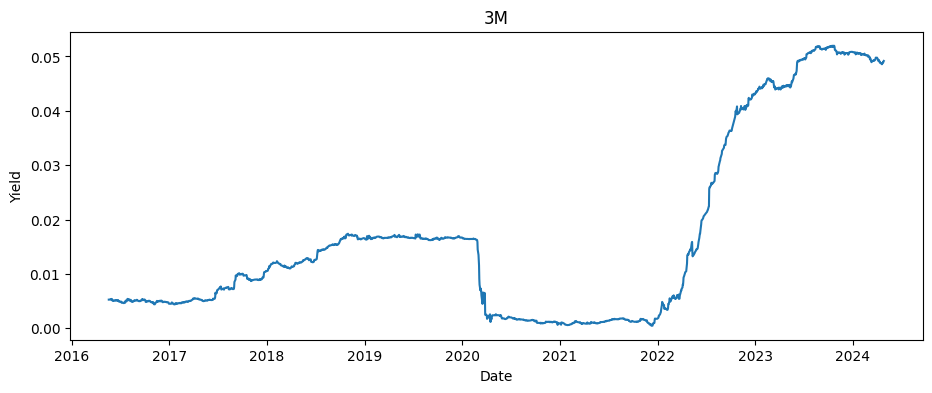

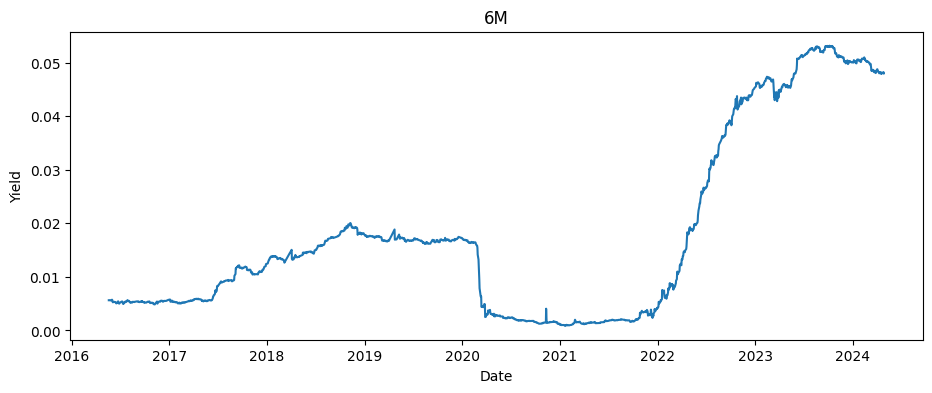

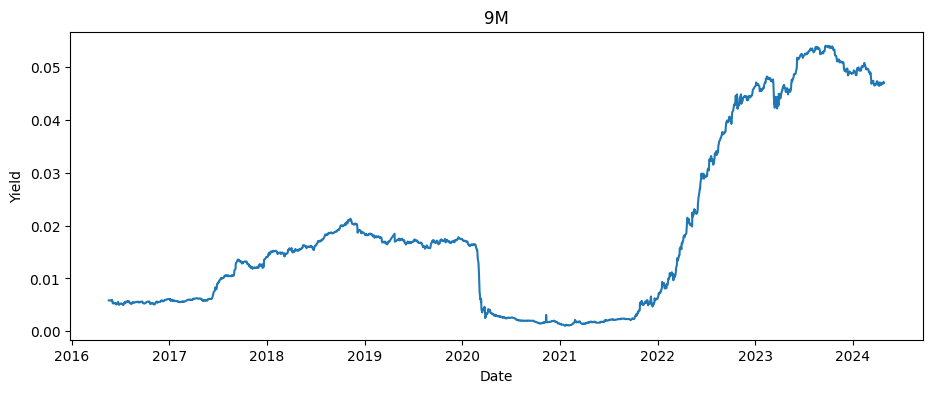

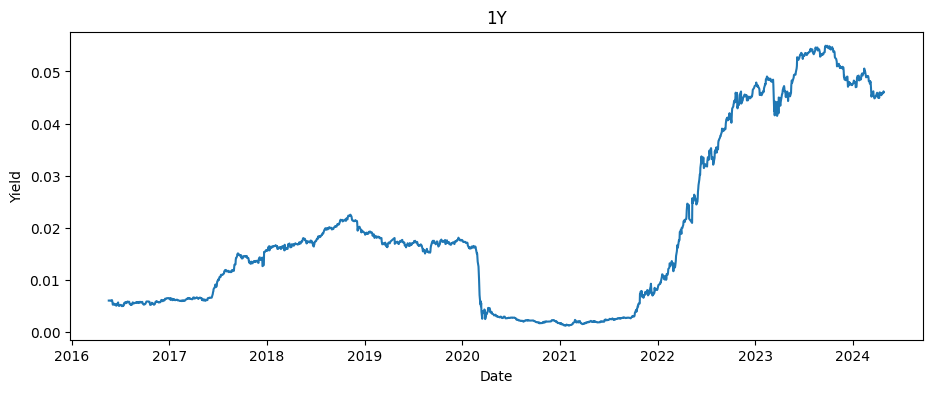

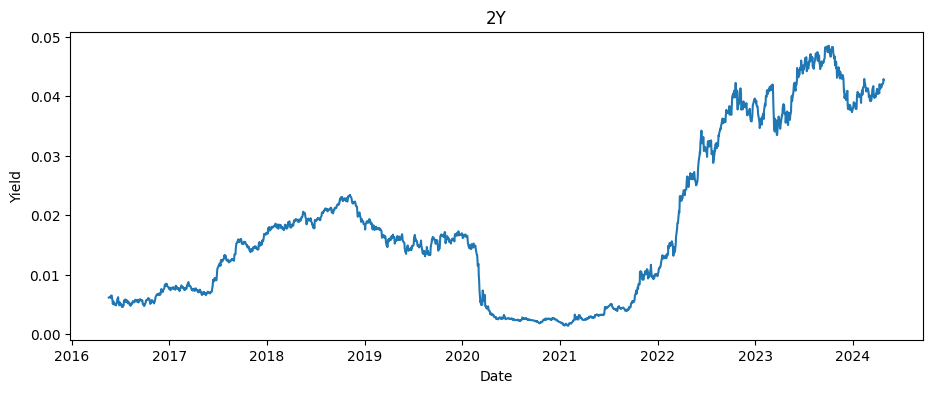

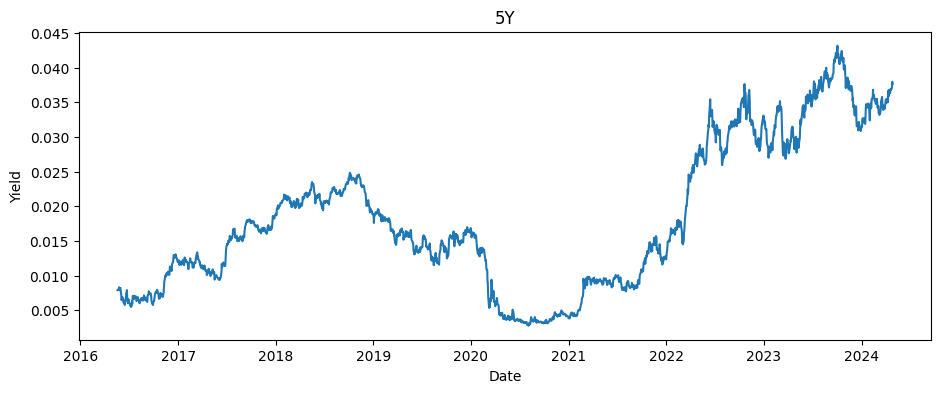

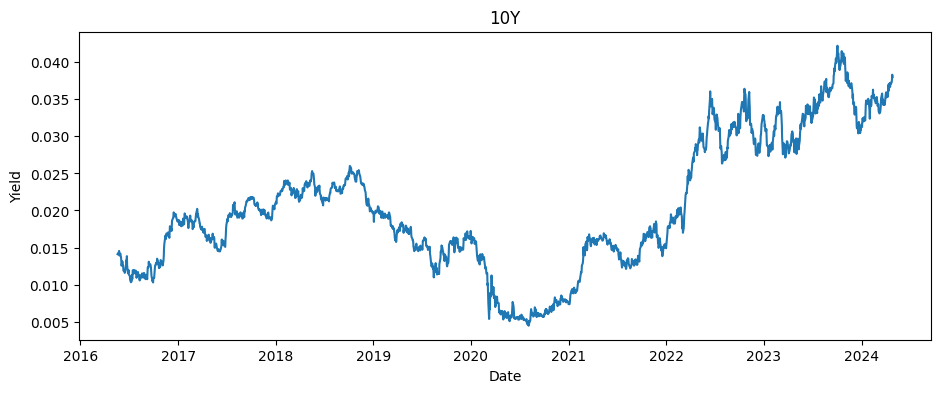

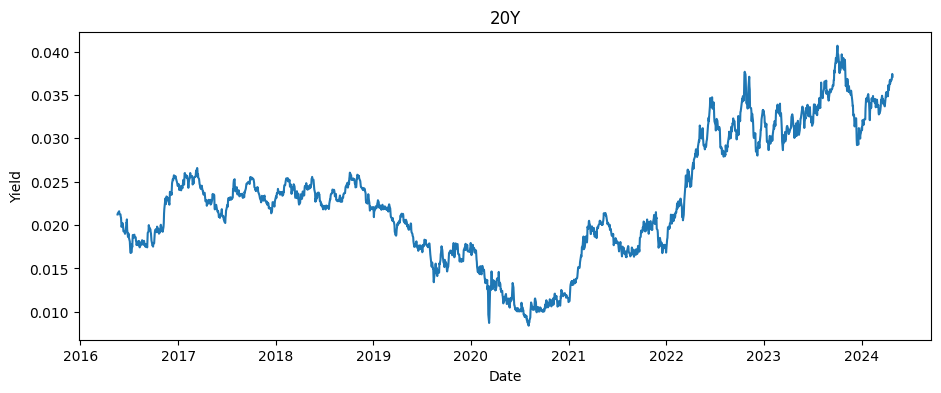

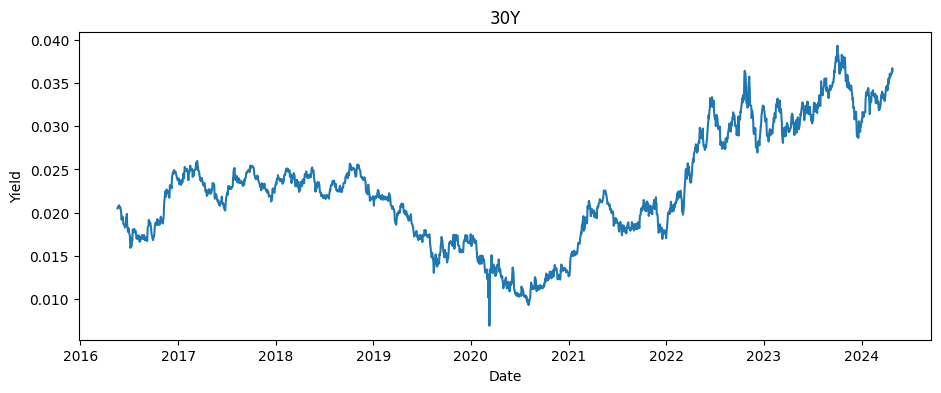

In [13]:
for c in df.columns[1:]:

    plt.figure(figsize=(11,4))

    plt.plot(
        df["Date"],
        df[c]
    )

    plt.title(c)

    plt.xlabel("Date")

    plt.ylabel("Yield")

    plt.show()

Yield
=
market-implied annualized return

## Yield Behaviour During COVID Period

A noticeable decline in yields is observed around the COVID period (2020). The decrease is visible across both short-term and long-term maturities, indicating that the entire yield curve shifted downward rather than only a specific segment.

One possible explanation is the response of central banks and financial markets during the economic slowdown. To support economic activity, interest rates were reduced, making borrowing cheaper and encouraging spending and investment. At the same time, investors shifted toward safer assets such as government bonds, increasing bond demand.

Since bond prices and yields move inversely, higher demand for bonds increased bond prices and resulted in lower yields across maturities.


In [14]:
df.duplicated().sum()

np.int64(0)

No duplicate observations detected.

In [15]:
df["weekday"]=df["Date"].dt.day_name()

df["weekday"].value_counts()

,count
weekday,
Thursday,411
Wednesday,409
Tuesday,405
Friday,398
Monday,353


No obvious non-trading day anomalies detected.

In [16]:
df["gap"]=df["Date"].diff()

df["gap"].value_counts()

,count
gap,
1 days,1551
3 days,339
4 days,70
2 days,8
5 days,7


## Trading Calendar Validation

Date-gap analysis shows that most observations are separated by one trading day. Larger gaps of three to five days appear occasionally and are consistent with weekends and market holidays rather than missing data.

Therefore, no major non-trading day anomalies were identified.

In [17]:
df=df.drop(
columns=[
"weekday",
"gap"
],
errors="ignore"
)

In [18]:
df.columns

Index(['Date', '3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y'], dtype='object')

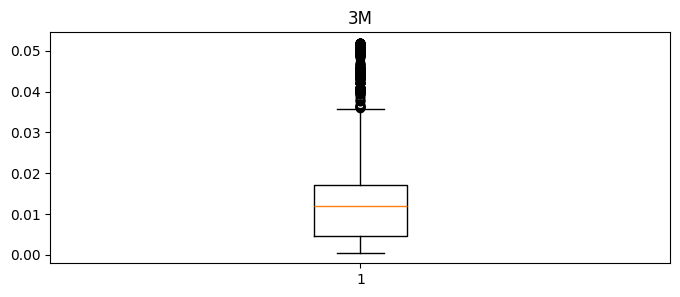

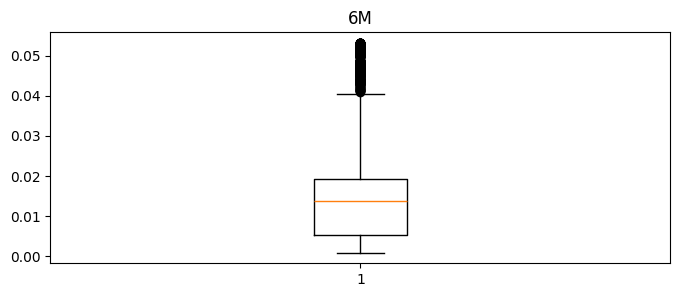

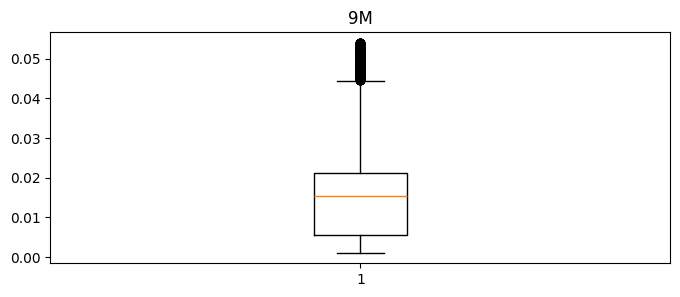

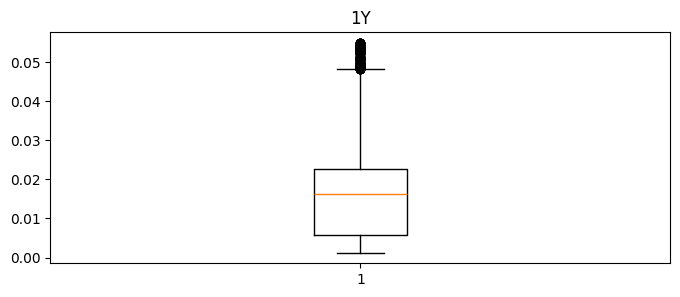

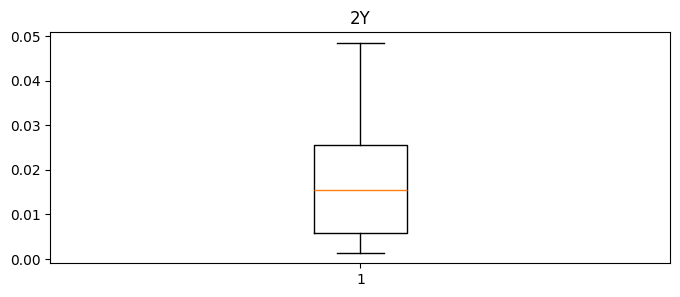

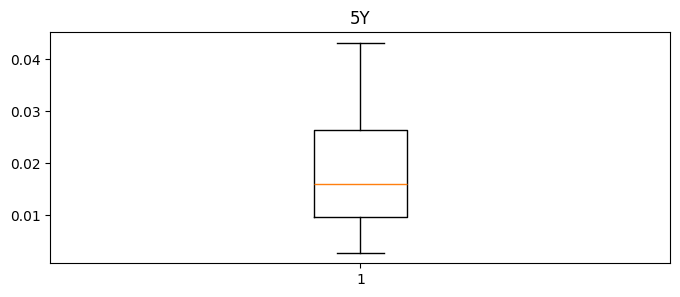

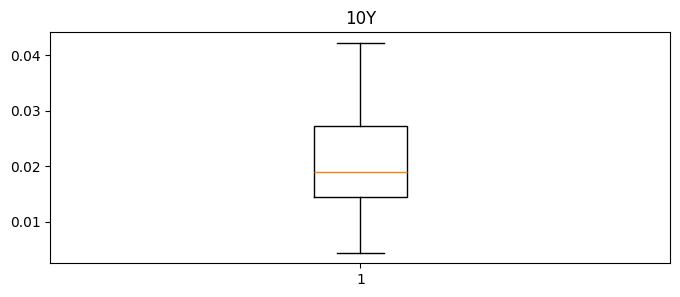

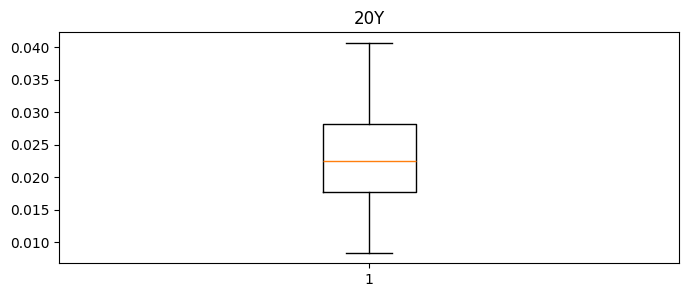

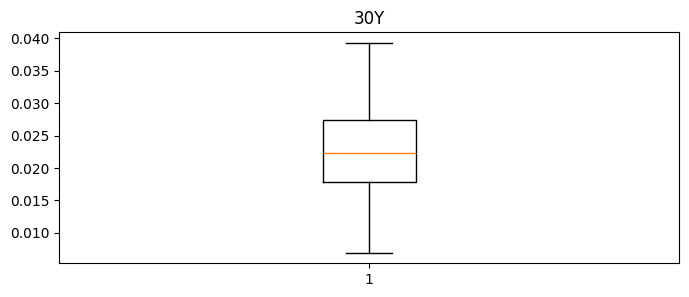

In [19]:
for c in df.columns[1:]:

    plt.figure(figsize=(8,3))

    plt.boxplot(df[c])

    plt.title(c)

    plt.show()

In [20]:
Q1=df.iloc[:,1:10].quantile(0.25)

Q3=df.iloc[:,1:10].quantile(0.75)

IQR=Q3-Q1

outlier_mask=(
(df.iloc[:,1:10]<(Q1-1.5*IQR))
|
(df.iloc[:,1:10]>(Q3+1.5*IQR))
)

outlier_mask.sum()

,0
3M,394
6M,383
9M,327
1Y,184
2Y,0
5Y,0
10Y,0
20Y,0
30Y,0


## Outlier Analysis

Outlier detection was performed using the Interquartile Range (IQR) method.

A relatively high number of observations were flagged in short-term maturities (3M–1Y), while long-term maturities showed almost no outliers.

These observations were retained because they likely represent genuine market conditions, including stress periods and changes in interest-rate environments rather than data errors.

Therefore, no automatic outlier removal was applied.

In [21]:
short_rate=df["3M"]

short_rate.head()

,3M
0,0.005283
1,0.005286
2,0.005298
3,0.005351
4,0.005354


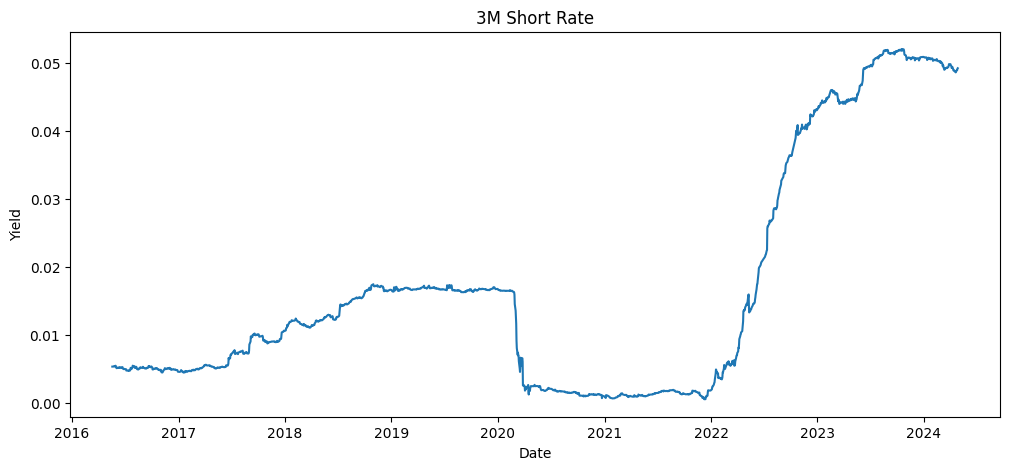

In [22]:
plt.figure(figsize=(12,5))

plt.plot(
df["Date"],
short_rate
)

plt.title(
"3M Short Rate"
)

plt.xlabel("Date")

plt.ylabel("Yield")

plt.show()

## Short Rate Behaviour

The 3-month yield series shows distinct interest-rate regimes over time. From 2016 to 2019, yields gradually increased and remained relatively stable. Around 2020, a sharp decline is observed, corresponding to a major market shift. After 2022, the short rate increased rapidly and reached significantly higher levels.

These changes suggest that short-term yields exhibit strong time-varying behaviour and may not fully follow a simple stationary mean-reverting process over the entire sample period.


In [23]:
from statsmodels.tsa.stattools import adfuller

result=adfuller(short_rate)

print("ADF Statistic:",result[0])

print("p-value:",result[1])

ADF Statistic: 0.0002652170256807046
p-value: 0.9585540138274081


## Stationarity Analysis

Stationarity of the 3-month yield series was evaluated using the Augmented Dickey–Fuller (ADF) test.

The test returned a p-value greater than 0.05, indicating failure to reject the null hypothesis of a unit root.

This suggests that the short-rate series is non-stationary over the full sample period and exhibits changing market regimes over time. Such behaviour may limit the ability of a single-factor CIR model with constant parameters to fully capture long-term market dynamics.


# **Base CIR Model**

The Cox–Ingersoll–Ross (CIR) model is a stochastic short-rate model used to describe interest-rate evolution through a mean-reverting square-root process.


In [24]:
from scipy.optimize import minimize
from scipy.stats import pearsonr

def cir_B(tau, kappa, sigma):
    """
    Computes the B(t,T) term used in the CIR bond pricing equation.

    Parameters:
    tau   : Time remaining until maturity
    kappa : Mean reversion speed
    sigma : Interest rate volatility
    """

    # Calculate the auxiliary CIR parameter
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)

    # Construct the analytical numerator and denominator separately
    numerator = 2 * (np.exp(gamma * tau) - 1)

    denominator = (
        (gamma + kappa)
        * (np.exp(gamma * tau) - 1)
        + 2 * gamma
    )

    return numerator / denominator


def cir_A(tau, kappa, theta, sigma):
    """
    Computes the A(t,T) term used in the CIR bond pricing equation.

    Parameters:
    tau   : Time remaining until maturity
    kappa : Mean reversion speed
    theta : Long-run average interest rate
    sigma : Interest rate volatility
    """

    # Auxiliary parameter appearing in the CIR closed-form solution
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)

    # Components of the CIR A-factor expression
    numerator = (
        2 * gamma
        * np.exp((kappa + gamma) * tau / 2)
    )

    denominator = (
        (gamma + kappa)
        * (np.exp(gamma * tau) - 1)
        + 2 * gamma
    )

    # Exponent controlling long-run mean reversion behaviour
    power = (2 * kappa * theta) / sigma**2

    return (numerator / denominator) ** power


def cir_yield(tau, r0, kappa, theta, sigma):
    """
    Calculates the theoretical zero-coupon yield implied by the CIR model.

    Parameters:
    tau   : Time to maturity
    r0    : Current short rate
    kappa : Mean reversion speed
    theta : Long-run average rate
    sigma : Volatility parameter
    """

    # Obtain the affine term-structure coefficients
    B = cir_B(tau, kappa, sigma)

    A = cir_A(tau, kappa, theta, sigma)

    # Convert bond pricing factors into yield form
    return (B * r0 - np.log(A)) / tau

In [25]:

# Create a working copy so the original dataset remains unchanged
df_pct = df.copy()

# Yield columns used throughout the calibration and prediction stages
yield_cols = [
    '3M', '6M', '9M', '1Y',
    '2Y', '5Y', '10Y', '20Y', '30Y'
]

# Corresponding maturity values (in years) aligned with yield_cols
maturities = np.array([
    0.25, 0.5, 0.75, 1,
    2, 5, 10, 20, 30
])

# Convert yields from decimal format to percentage format
# Example: 0.045 becomes 4.5%
# This improves interpretability and keeps calibration values on a convenient scale
df_pct[yield_cols] = df_pct[yield_cols] * 100

# Verification check
print("Yields converted to percentage form")

print(
    f"Sample 3M yield: "
    f"{df_pct['3M'].iloc[0]:.5f}%"
)

Yields converted to percentage form
Sample 3M yield: 0.52827%


Convert from decimal form (0.005) to percentage form (0.5%)

This is necessary so the optimizer works with meaningful numbers

In [26]:
# We calibrate on 2016-2019 stable period first
# to understand the base model behavior
#we willdo Full dataset calibration comes later
mask = (df_pct['Date'] >= '2016-01-01') & (df_pct['Date'] <= '2019-12-31')
df_stable = df_pct[mask].reset_index(drop=True)

print(f"Stable period rows: {len(df_stable)}")
print(f"Date range: {df_stable['Date'].min()} to {df_stable['Date'].max()}")
print(f"Average 3M yield: {df_stable['3M'].mean():.2f}%")

Stable period rows: 902
Date range: 2016-05-19 00:00:00 to 2019-12-31 00:00:00
Average 3M yield: 1.12%


We calibrate on 2016-2019 stable period first
to understand the base model behavior,
Full dataset calibration comes later in Phase C

In [27]:
def calibration_error(params, df, maturities):
    """
    Computes the aggregate calibration loss used during parameter estimation.

    Parameters:
    params     : Candidate CIR parameters [kappa, theta, sigma]
    df         : Training dataset containing observed yield curves
    maturities : Maturity values corresponding to each yield column
    """

    kappa, theta, sigma = params

    # Enforce positivity constraints required by the CIR framework
    # Invalid parameter combinations receive a large penalty
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10

    total_error = 0

    # Reduce computational cost by evaluating every 5th observation
    # This speeds up optimization while preserving the overall curve structure
    df_sample = df.iloc[::5].reset_index(drop=True)

    # Evaluate model fit across sampled dates and all maturities
    for _, row in df_sample.iterrows():

        # Use the observed 3M yield as a proxy for the short rate
        r0 = row['3M']

        for i, col in enumerate(yield_cols):

            tau = maturities[i]

            try:

                # Generate model-implied yield and compare it to market observations
                model_yield = cir_yield(
                    tau,
                    r0,
                    kappa,
                    theta,
                    sigma
                )

                actual_yield = row[col]

                # Accumulate squared pricing errors
                total_error += (
                    model_yield - actual_yield
                ) ** 2

            except:

                # Penalize unstable parameter proposals encountered during optimization
                total_error += 1e6

    return total_error


# Verification message confirming successful function creation
print("Calibration error function defined")

Calibration error function defined


This function measures how wrong our model is
for a given set of parameters kappa, theta, sigma
The optimizer will minimize this error

In [28]:
from scipy.optimize import differential_evolution

# Define feasible search ranges for the CIR parameters
# kappa : controls how quickly rates revert to the long-run level
# theta : long-run equilibrium interest rate
# sigma : volatility of the short-rate process
parameter_bounds = [
    (0.01, 5.0),   # kappa
    (0.10, 10.0),  # theta
    (0.01, 3.0)    # sigma
]

print("Running CIR calibration on the stable period (2016-2019)...")

# Perform global optimization using Differential Evolution
# This approach is less sensitive to local minima than traditional gradient methods
result = differential_evolution(
    calibration_error,
    bounds=parameter_bounds,
    args=(df_stable, maturities),  # Inputs passed to the calibration objective function
    seed=42,                       # Fixed seed for reproducible calibration results
    maxiter=2100,                  # Maximum number of optimization generations
    tol=1e-8,                      # Convergence tolerance
    disp=True                      # Display optimization progress during execution
)

# Extract calibrated CIR parameters from the optimizer output
kappa, theta, sigma = result.x

# Display final calibration results
print("\nOptimized CIR Parameters")
print("-" * 35)
print(f"kappa = {kappa:.4f}")
print(f"theta = {theta:.4f}")
print(f"sigma = {sigma:.4f}")
print(f"Optimization successful: {result.success}")

Running CIR calibration on the stable period (2016-2019)...
differential_evolution step 1: f(x)= 154.69182904180474
differential_evolution step 2: f(x)= 154.69182904180474
differential_evolution step 3: f(x)= 154.69182904180474
differential_evolution step 4: f(x)= 154.69182904180474
differential_evolution step 5: f(x)= 154.46279035725243
differential_evolution step 6: f(x)= 154.46279035725243
differential_evolution step 7: f(x)= 146.87318490963386
differential_evolution step 8: f(x)= 146.87318490963386
differential_evolution step 9: f(x)= 138.4249021185156
differential_evolution step 10: f(x)= 138.4249021185156
differential_evolution step 11: f(x)= 135.7736387172743
differential_evolution step 12: f(x)= 135.7736387172743
differential_evolution step 13: f(x)= 135.7736387172743
differential_evolution step 14: f(x)= 135.7736387172743
differential_evolution step 15: f(x)= 129.97756189476218
differential_evolution step 16: f(x)= 129.97756189476218
differential_evolution step 17: f(x)= 129.3

Search space for CIR parameters

In [29]:
# Evaluate the Feller condition using the calibrated CIR parameters
# Condition: 2 * kappa * theta >= sigma^2

lhs_value = 2 * kappa * theta

rhs_value = sigma ** 2

# Display the quantities involved in the positivity condition
print("Feller Condition Analysis")
print("-" * 30)

print(
    f"Left Side  (2*kappa*theta) : "
    f"{lhs_value:.6f}"
)

print(
    f"Right Side (sigma^2)       : "
    f"{rhs_value:.6f}"
)

# Assess whether mean reversion is strong enough to offset volatility effects
# Satisfying this condition helps ensure that short rates remain positive
if lhs_value >= rhs_value:

    print("\nCondition Satisfied")

    print(
        "Mean reversion dominates the volatility component."
    )

    print(
        "The CIR process is expected to maintain positive interest rates."
    )

else:

    print("\nCondition Violated")

    print(
        "Volatility pressure exceeds the theoretical positivity boundary."
    )

    print(
        "The model may approach or hit zero-rate levels."
    )

    print(
        "This should be reported as a limitation of the calibrated CIR model."
    )

Feller Condition Analysis
------------------------------
Left Side  (2*kappa*theta) : 1.169886
Right Side (sigma^2)       : 0.003519

Condition Satisfied
Mean reversion dominates the volatility component.
The CIR process is expected to maintain positive interest rates.


In [30]:
# Validate the calibrated parameter set on the entire dataset
print("Evaluating calibrated CIR parameters on the complete dataset...")

overall_error = calibration_error(
    [kappa, theta, sigma],
    df_pct,
    maturities
)

# Report the total fitting error across all available observations
print(
    f"Calibration error on full sample: "
    f"{overall_error:.6f}"
)

# Measure historical volatility using day-to-day changes in the 3M yield
rate_movements = (
    df_pct["3M"]
    .diff()
    .dropna()
)

observed_volatility = rate_movements.std()

# Compare market-observed volatility with the calibrated CIR volatility parameter
print("\nVolatility Comparison")
print("-" * 30)

print(
    f"Observed 3M Volatility : "
    f"{observed_volatility:.4f}%"
)

print(
    f"CIR Model Volatility   : "
    f"{sigma:.4f}%"
)

Evaluating calibrated CIR parameters on the complete dataset...
Calibration error on full sample: 540.342035

Volatility Comparison
------------------------------
Observed 3M Volatility : 0.0234%
CIR Model Volatility   : 0.0593%


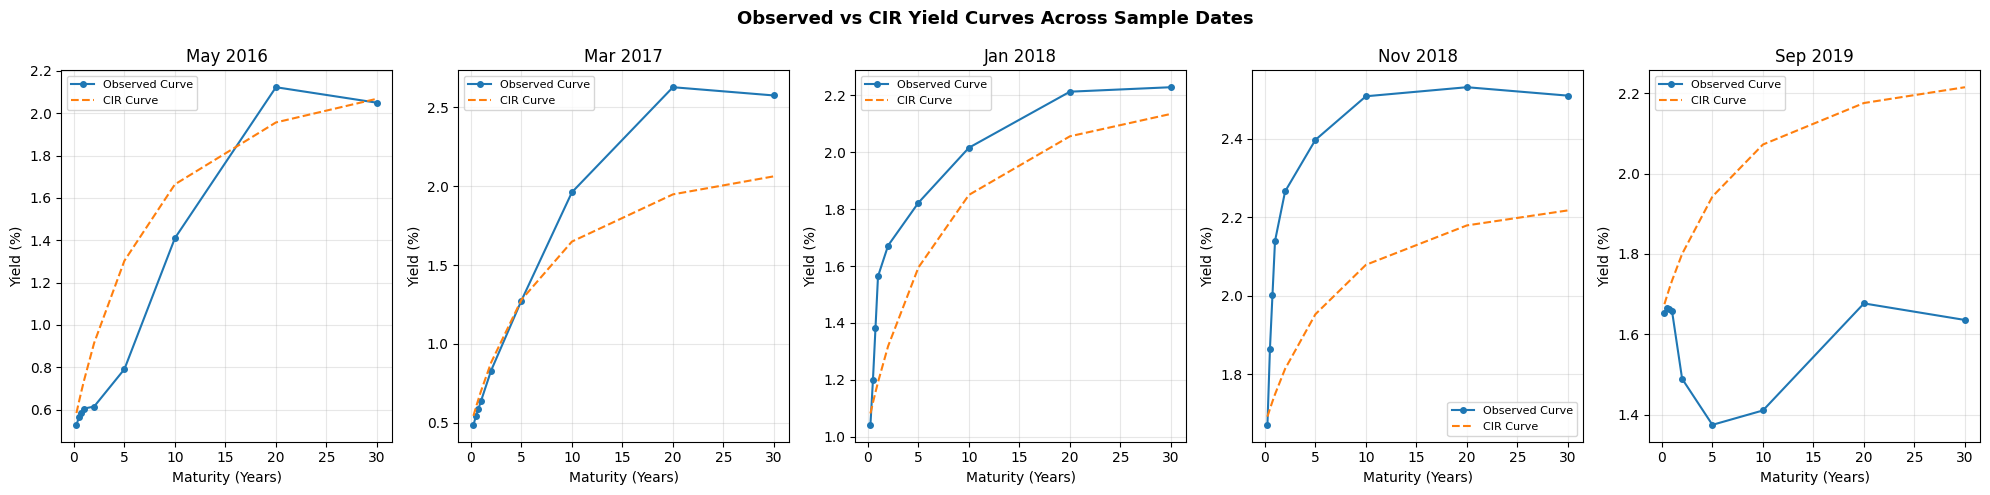

In [31]:
# Select representative dates from the calibration period
# These snapshots help assess how well the CIR curve matches market yields over time

selected_rows = [0, 200, 400, 600, 800]

period_names = [
    "May 2016",
    "Mar 2017",
    "Jan 2018",
    "Nov 2018",
    "Sep 2019"
]

# Create a multi-panel figure for side-by-side yield curve comparison
fig, axes = plt.subplots(
    nrows=1,
    ncols=5,
    figsize=(20, 5)
)

for plot_id, (row_id, period) in enumerate(
    zip(selected_rows, period_names)
):

    current_row = df_pct.iloc[row_id]

    # Use the observed 3M yield as the short-rate input for the CIR model
    short_rate = current_row["3M"]

    # Extract the actual market yield curve for the selected date
    observed_curve = [
        current_row[col]
        for col in yield_cols
    ]

    # Generate model-implied yields using the calibrated CIR parameters
    cir_curve = []

    for maturity in maturities:

        try:

            predicted_yield = cir_yield(
                maturity,
                short_rate,
                kappa,
                theta,
                sigma
            )

            cir_curve.append(predicted_yield)

        except Exception:

            # Preserve curve structure if numerical issues occur
            cir_curve.append(np.nan)

    # Plot observed market yields
    axes[plot_id].plot(
        maturities,
        observed_curve,
        "o-",
        label="Observed Curve",
        linewidth=1.5,
        markersize=4
    )

    # Plot CIR model reconstructed yield curve
    axes[plot_id].plot(
        maturities,
        cir_curve,
        "--",
        label="CIR Curve",
        linewidth=1.5
    )

    # Configure subplot formatting and labels
    axes[plot_id].set_title(
        period,
        fontsize=12
    )

    axes[plot_id].set_xlabel(
        "Maturity (Years)"
    )

    axes[plot_id].set_ylabel(
        "Yield (%)"
    )

    axes[plot_id].grid(
        alpha=0.3
    )

    axes[plot_id].legend(
        fontsize=8
    )

# Add a global title summarizing the comparison
plt.suptitle(
    "Observed vs CIR Yield Curves Across Sample Dates",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [32]:
test_full = pd.read_csv('test_data.csv')
test_full.head()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
0,2024-04-29,0.049144,0.048110,0.047051,0.046014,0.042459
1,2024-04-30,0.049156,0.048084,0.047068,0.046093,0.042923
2,2024-05-01,0.049100,0.048083,0.047029,0.046004,0.042449
3,2024-05-02,0.048921,0.047969,0.046831,0.045710,0.041908
4,2024-05-03,0.048633,0.047609,0.046424,0.045235,0.041072


In [33]:
# Load full test data with all 9 maturities
test_full = pd.read_csv('test_data.csv')

# Rename columns — same as training data
test_full = test_full.rename(columns={
    'Date'       : 'Date',
    ' ZC025YR'   : '3M',
    ' ZC050YR'   : '6M',
    ' ZC075YR'   : '9M',
    ' ZC100YR'   : '1Y',
    ' ZC200YR'   : '2Y',

})



In [34]:
# Fix dates and convert to percentage form
yield_cols_test = ['3M', '6M', '9M', '1Y', '2Y']

test_full['Date'] = pd.to_datetime(test_full['Date'])
test_full = test_full.sort_values('Date').reset_index(drop=True)
test_full[yield_cols_test] = test_full[yield_cols_test] * 100

In [35]:


print("Full test data loaded successfully")
print(f"Shape: {test_full.shape}")
print(f"Date range: {test_full['Date'].min()} to {test_full['Date'].max()}")
print(f"\nFirst 3 rows:")
print(test_full.head(3))


Full test data loaded successfully
Shape: (495, 6)
Date range: 2024-04-29 00:00:00 to 2026-04-29 00:00:00

First 3 rows:
        Date       3M       6M       9M       1Y       2Y
0 2024-04-29  4.91444  4.81098  4.70505  4.60144  4.24587
1 2024-04-30  4.91565  4.80837  4.70676  4.60933  4.29233
2 2024-05-01  4.91005  4.80828  4.70293  4.60044  4.24488


In [36]:
from sklearn.metrics import r2_score

# Store observed market yields and corresponding CIR estimates
actual_all = []
model_all = []

# Measure the quality of fit over the stable calibration sample
for _, current_row in df_stable.iterrows():

    # Use the 3M yield as the short-rate input to the CIR model
    short_rate = current_row["3M"]

    for maturity, yield_name in zip(
        maturities,
        yield_cols
    ):

        try:

            # Generate the model-implied yield for the selected maturity
            model_yield = cir_yield(
                maturity,
                short_rate,
                kappa,
                theta,
                sigma
            )

            # Collect actual and predicted values for performance evaluation
            actual_all.append(
                current_row[yield_name]
            )

            model_all.append(
                model_yield
            )

        except (
            ValueError,
            ZeroDivisionError,
            FloatingPointError
        ):

            # Ignore numerical issues and continue processing
            continue

# Compute the overall R² score across all maturities and dates
r2 = r2_score(
    actual_all,
    model_all
)

# Display the explanatory power of the calibrated CIR model
print(f"R² Score (Stable Period): {r2:.4f}")

print(
    f"Variance Explained by CIR Model: "
    f"{r2 * 100:.1f}%"
)

# Compare the result against the project performance target
if r2 >= 0.85:

    print(
        "✓ Requirement satisfied (R² ≥ 0.85)"
    )

else:

    print(
        "✗ Requirement not satisfied"
    )

    print(
        "Additional modelling improvements will be explored later"
    )

R² Score (Stable Period): 0.7736
Variance Explained by CIR Model: 77.4%
✗ Requirement not satisfied
Additional modelling improvements will be explored later


## Base CIR Model Limitation

The base CIR model achieved an R² value of 0.7736 during the stable calibration period. An examination of the yield curve plots shows a consistent pattern: the model tends to overestimate yields at shorter maturities while failing to fully capture the steepness of the curve at medium maturities.

This behavior reflects a fundamental limitation of the single-factor CIR framework. Since the model generally produces smooth and gradually increasing yield curves, it struggles to represent more complex market structures such as:

1. Inverted yield curves, as observed in September 2019
2. Humped yield curves
3. Rapid changes in short-term yield dynamics

The R² value of 0.7736 serves as a useful baseline for model performance. To overcome these limitations, the CIR++ extension introduces a time-dependent shift function, allowing the model to fit the observed yield curve more accurately and potentially achieve an R² value above 0.85.


In [37]:
# Import the test dataset containing the 3M short-rate information
test = pd.read_csv("test_data_3M.csv")

# Rename columns for consistency with the training dataset
test = test.rename(
    columns={
        "Date": "Date",
        " ZC025YR": "3M"
    }
)

# Convert the date column into datetime format
test["Date"] = pd.to_datetime(test["Date"])

# Arrange observations in chronological order
test = (
    test
    .sort_values("Date")
    .reset_index(drop=True)
)

# Convert rates to percentage form to match the calibration dataset
test["3M"] = test["3M"] * 100

print("Test dataset loaded successfully")
print("-" * 40)
print(f"Shape      : {test.shape}")
print(
    f"Date Range : {test['Date'].min()} to "
    f"{test['Date'].max()}"
)

print("\nSample Records:")
print(test.sample(3))

Test dataset loaded successfully
----------------------------------------
Shape      : (495, 2)
Date Range : 2024-04-29 00:00:00 to 2026-04-29 00:00:00

Sample Records:
          Date       3M
155 2024-12-11  3.14396
194 2025-02-07  2.86246
9   2024-05-10  4.87540


In [38]:
# Generate yield curve forecasts from the observed 3M rate
# using the calibrated CIR parameters

pred_maturities = [0.5, 0.75, 1, 2, 5, 10, 20, 30]

pred_cols = [
    '6M',
    '9M',
    '1Y',
    '2Y',
    '5Y',
    '10Y',
    '20Y',
    '30Y'
]

predictions = []

for _, current_row in test.iterrows():

    short_rate = current_row['3M']

    daily_preds = {
        'Date': current_row['Date'],
        '3M': short_rate
    }

    for maturity_name, maturity_years in zip(
        pred_cols,
        pred_maturities
    ):

        try:

            predicted_yield = cir_yield(
                maturity_years,
                short_rate,
                kappa,
                theta,
                sigma
            )

            daily_preds[maturity_name] = predicted_yield

        except Exception:

            daily_preds[maturity_name] = np.nan

    predictions.append(daily_preds)

# Convert prediction records into a DataFrame
df_pred = pd.DataFrame(predictions)

print("Yield curve forecasts generated successfully")
print("-" * 40)
print(f"Output shape : {df_pred.shape}")

print("\nPreview of predictions:")
print(df_pred.sample(3))

Yield curve forecasts generated successfully
----------------------------------------
Output shape : (495, 10)

Preview of predictions:
          Date       3M        6M        9M        1Y        2Y        5Y  \
2   2024-05-01  4.91005  4.757575  4.685469  4.615995  4.362640  3.794416   
80  2024-08-22  4.20690  4.096362  4.044029  3.993572  3.809294  3.394631   
154 2024-12-10  3.13789  3.091108  3.068837  3.047291  2.968035  2.786833   

          10Y       20Y       30Y  
2    3.254444  2.811026  2.640759  
80   2.999207  2.673846  2.548840  
154  2.611167  2.465290  2.409094  


In [51]:
# Select the post-2022 period for a separate CIR calibration
recent_mask = df_pct["Date"] >= "2022-01-01"

df_recent = (
    df_pct[recent_mask]
    .reset_index(drop=True)
)

print(f"Number of observations in recent sample: {len(df_recent)}")
print("Starting optimization on the recent-rate regime...")

recent_bounds = [
    (0.01, 5.0),   # kappa
    (0.10, 10.0),  # theta
    (0.01, 3.0)    # sigma
]

result_recent = differential_evolution(
    calibration_error,
    bounds=recent_bounds,
    args=(df_recent, maturities),
    seed=42,
    maxiter=2500,
    tol=1e-8,
    disp=False
)

kappa_r, theta_r, sigma_r = result_recent.x

print("\nCalibrated Parameters (Recent Period)")
print("-" * 40)
print(f"kappa : {kappa_r:.4f}")
print(f"theta : {theta_r:.4f} ({theta_r:.2f}%)")
print(f"sigma : {sigma_r:.4f}")

Number of observations in recent sample: 576
Starting optimization on the recent-rate regime...

Calibrated Parameters (Recent Period)
----------------------------------------
kappa : 0.2570
theta : 8.6970 (8.70%)
sigma : 0.8770


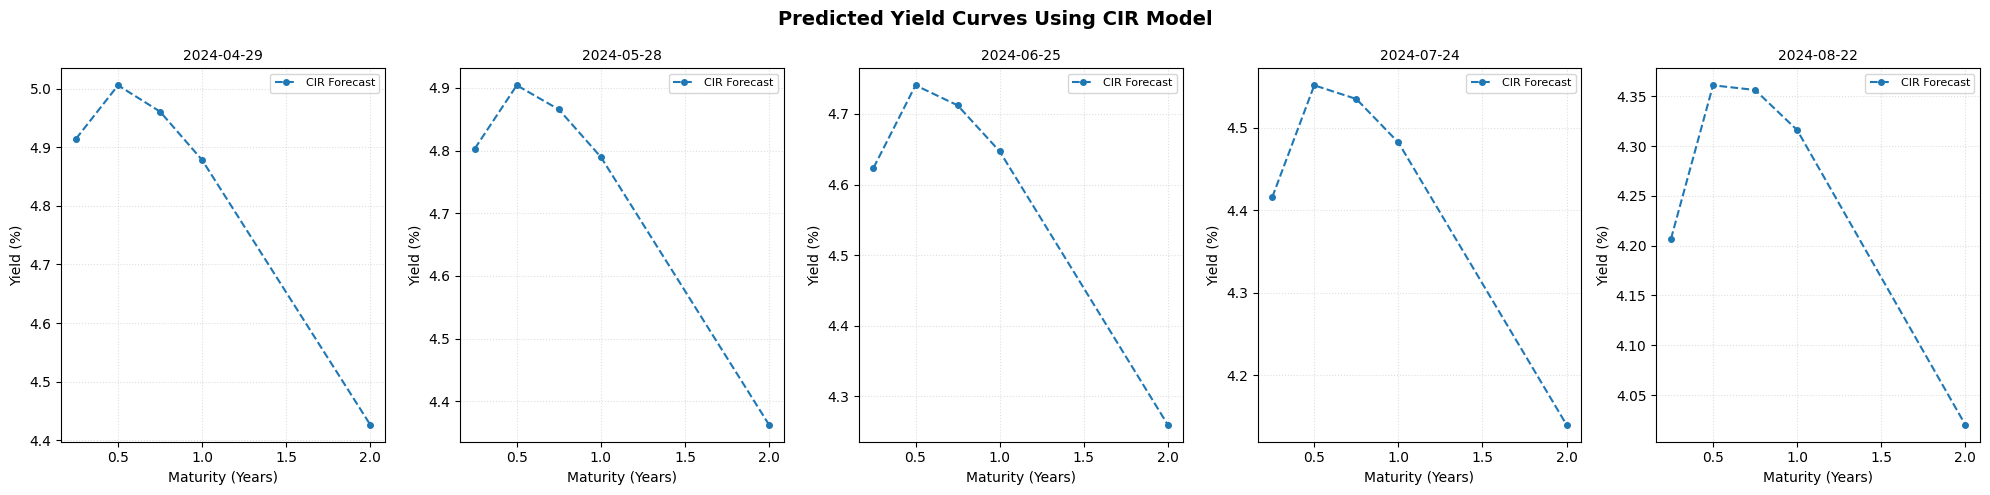

In [52]:
# Select a few dates from the forecast period for visualization
sample_indices = [0, 20, 40, 60, 80]

# Maturity structure corresponding to the predicted yields
all_maturities = [0.25, 0.5, 0.75, 1.0, 2.0]
all_pred_cols = ["3M", "6M", "9M", "1Y", "2Y"]

# Create figure for comparing predicted yield curves over time
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sample_indices),
    figsize=(20, 5)
)

for plot_no, row_idx in enumerate(sample_indices):

    if row_idx >= len(df_pred):
        continue

    current_row = df_pred.iloc[row_idx]

    predicted_curve = [
        current_row[col]
        for col in all_pred_cols
    ]

    axes[plot_no].plot(
        all_maturities,
        predicted_curve,
        marker="o",
        linestyle="--",
        linewidth=1.5,
        markersize=4,
        label="CIR Forecast"
    )

    axes[plot_no].set_title(
        current_row["Date"].strftime("%Y-%m-%d"),
        fontsize=10
    )

    axes[plot_no].set_xlabel(
        "Maturity (Years)"
    )

    axes[plot_no].set_ylabel(
        "Yield (%)"
    )

    axes[plot_no].grid(
        alpha=0.4,
        linestyle=":"
    )

    axes[plot_no].legend(
        fontsize=8
    )

plt.suptitle(
    "Predicted Yield Curves Using CIR Model",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [53]:
# Import the complete test dataset containing observed market yields
test_full = pd.read_csv("test_data.csv")

# Rename columns to match the maturity labels used throughout the project
test_full = test_full.rename(
    columns={
        "Date": "Date",
        " ZC025YR": "3M",
        " ZC050YR": "6M",
        " ZC075YR": "9M",
        " ZC100YR": "1Y",
        " ZC200YR": "2Y",
    }
)

# Convert date values and arrange records chronologically
test_full["Date"] = pd.to_datetime(
    test_full["Date"]
)

test_full = (
    test_full
    .sort_values("Date")
    .reset_index(drop=True)
)

# Express yields in percentage terms for consistency
new_yield_cols = [
    "3M",
    "6M",
    "9M",
    "1Y",
    "2Y"
]

test_full[new_yield_cols] = (
    test_full[new_yield_cols] * 100
)

print("Full test dataset loaded successfully")
print("-" * 40)
print(f"Dataset shape : {test_full.shape}")

print(
    f"Sample period : "
    f"{test_full['Date'].min()} to "
    f"{test_full['Date'].max()}"
)

print("\nAvailable columns:")
print(test_full.columns.tolist())

print("\nsample 3 observations:")
print(test_full.sample(3))

Full test dataset loaded successfully
----------------------------------------
Dataset shape : (495, 6)
Sample period : 2024-04-29 00:00:00 to 2026-04-29 00:00:00

Available columns:
['Date', '3M', '6M', '9M', '1Y', '2Y']

sample 3 observations:
          Date       3M       6M       9M       1Y       2Y
299 2025-07-10  2.64471  2.63809  2.61778  2.61138  2.68594
98  2024-09-18  4.00212  3.72789  3.46650  3.26488  2.86401
262 2025-05-16  2.59297  2.54346  2.51095  2.49099  2.52062


In [54]:
# Maturities available in the test dataset
compare_cols = ["6M", "9M", "1Y", "2Y"]

pred_maturities = [0.5, 0.75, 1.0, 2.0]

all_maturities = [0.25, 0.5, 0.75, 1.0, 2.0]

actual_all = []
model_all = []
predictions = []

for _, current_row in test_full.iterrows():

    short_rate = current_row["3M"]

    daily_preds = {
        "Date": current_row["Date"],
        "3M": short_rate
    }

    for maturity_name, maturity_years in zip(
        compare_cols,
        pred_maturities
    ):

        try:

            predicted_yield = cir_yield(
                maturity_years,
                short_rate,
                kappa_r,
                theta_r,
                sigma_r
            )

            daily_preds[maturity_name] = predicted_yield

            actual_all.append(
                current_row[maturity_name]
            )

            model_all.append(
                predicted_yield
            )

        except Exception:

            daily_preds[maturity_name] = np.nan

    predictions.append(daily_preds)

# Store all predicted curves
df_pred = pd.DataFrame(predictions)

# Evaluate out-of-sample performance
r2_test = r2_score(
    actual_all,
    model_all
)

print(f"Test Set R² Score: {r2_test:.4f}")
print(
    f"Variance Explained: "
    f"{r2_test * 100:.1f}%"
)

if r2_test >= 0.85:
    print("✓ Project target achieved (R² ≥ 0.85)")
else:
    print(
        f"✗ Below target by "
        f"{0.85 - r2_test:.4f}"
    )

Test Set R² Score: 0.5815
Variance Explained: 58.2%
✗ Below target by 0.2685


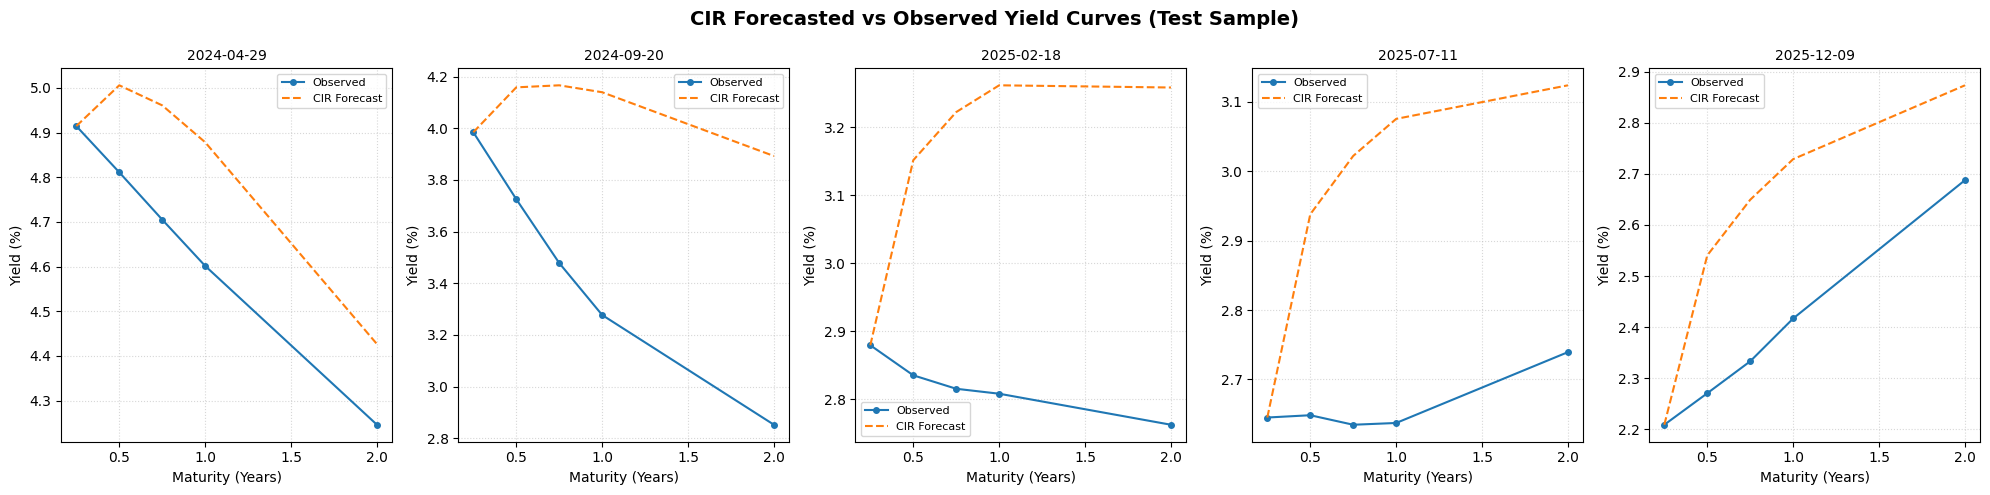

In [55]:
import matplotlib.pyplot as plt

# Maturity structure available in the test dataset
all_maturities = [0.25, 0.5, 0.75, 1.0, 2.0]

compare_cols = [
    "6M",
    "9M",
    "1Y",
    "2Y"
]

pred_maturities = [0.5, 0.75, 1.0, 2.0]

# Select representative dates from the test sample
sample_indices = [0, 100, 200, 300, 400]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sample_indices),
    figsize=(20, 5)
)

for plot_id, row_idx in enumerate(sample_indices):

    if row_idx >= len(test_full):
        continue

    current_row = test_full.iloc[row_idx]

    short_rate = current_row["3M"]

    current_date = current_row["Date"].strftime("%Y-%m-%d")

    # Observed market yield curve
    actual_yields = [
        current_row["3M"]
    ] + [
        current_row[col]
        for col in compare_cols
    ]

    # CIR-implied yield curve using recent-period calibration
    model_yields = [short_rate]

    for maturity in pred_maturities:

        predicted_yield = cir_yield(
            maturity,
            short_rate,
            kappa_r,
            theta_r,
            sigma_r
        )

        model_yields.append(predicted_yield)

    axes[plot_id].plot(
        all_maturities,
        actual_yields,
        "o-",
        linewidth=1.5,
        markersize=4,
        label="Observed"
    )

    axes[plot_id].plot(
        all_maturities,
        model_yields,
        "--",
        linewidth=1.5,
        label="CIR Forecast"
    )

    axes[plot_id].set_title(
        current_date,
        fontsize=10
    )

    axes[plot_id].set_xlabel(
        "Maturity (Years)"
    )

    axes[plot_id].set_ylabel(
        "Yield (%)"
    )

    axes[plot_id].grid(
        linestyle=":",
        alpha=0.5
    )

    axes[plot_id].legend(
        fontsize=8
    )

plt.suptitle(
    "CIR Forecasted vs Observed Yield Curves (Test Sample)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Prediction Challenge — Results and Base CIR Limitations

The base CIR model was tested on the out-of-sample period beginning in April 2024. Yield curves for maturities ranging from 6 months to 2 years were reconstructed using only the 3M rate as the input variable.

The model achieved an R² value of 0.5815 during the test period, meaning it explained about 58% of the variation in yields. This falls short of the target requirement of 0.85.

The main reason for this performance lies in the structure of the model itself. The CIR framework generates yield curves based only on the calibrated values of kappa, theta, and sigma, resulting in relatively smooth curve shapes. In contrast, the actual yield curves observed during the test period included inverted, flat, and humped structures that cannot be fully captured by a single-factor model with constant parameters.

Two important observations support this conclusion:

1. Base CIR R² during the stable 2016–2019 period = 0.7736
2. Base CIR R² during the 2024–2026 test period = 0.5815

The decline in performance shows that parameters estimated from historical data may lose effectiveness when market conditions change. The high-interest-rate and inverted yield curve environment of 2024–2026 was significantly different from the relatively stable period used for calibration.

These limitations provide a strong justification for using the CIR++ extension. By introducing a time-dependent shift function, phi, the model can better match the observed yield curve shape instead of relying entirely on fixed historical parameters.


## Model Extension — CIR++

One of the main limitations of the base CIR model is that it cannot accurately fit any arbitrary initial yield curve. This is because the shape of the curve is determined entirely by the fixed parameters kappa, theta, and sigma.

The CIR++ model, proposed by Brigo and Mercurio, addresses this issue by introducing a deterministic shift function called phi. The adjusted yield can be expressed as:

y_CIR++(τ) = y_CIR(τ) + φ(τ)

The shift function phi is calibrated so that the model matches the observed market yield curve exactly on the calibration date. As a result, CIR++ retains the mathematical simplicity and analytical advantages of the original CIR model while providing a much better fit to the initial term structure.


In [56]:
# ───────────────── CIR++ Extension ─────────────────
# The deterministic shift term phi(τ) adjusts the CIR curve
# so that it better matches the observed market term structure.

def compute_phi(
    r0,
    kappa,
    theta,
    sigma,
    market_yields,
    maturities
):
    """
    Calculate maturity-wise correction terms.

    phi(τ) = Observed Yield(τ) - CIR Yield(τ)

    These adjustments are later added to the
    theoretical CIR curve.
    """

    phi_values = []

    for maturity, observed_yield in zip(
        maturities,
        market_yields
    ):

        try:

            model_yield = cir_yield(
                maturity,
                r0,
                kappa,
                theta,
                sigma
            )

            phi_values.append(
                observed_yield - model_yield
            )

        except Exception:

            phi_values.append(0.0)

    return np.array(phi_values)


def cirpp_yield(
    tau,
    r0,
    kappa,
    theta,
    sigma,
    phi,
    maturities
):
    """
    Generate CIR++ yield estimates.

    Yield = CIR Yield + Interpolated Shift Term
    """

    cir_component = cir_yield(
        tau,
        r0,
        kappa,
        theta,
        sigma
    )

    shift_term = np.interp(
        tau,
        maturities,
        phi
    )

    return cir_component + shift_term


print("CIR++ helper functions are ready")

CIR++ helper functions are ready


In [57]:
# Use the most recent training observation as the calibration anchor
last_train_row = df_pct.tail(1).iloc[0]

# Extract the short-rate input and corresponding market yield curve
r0_calibration = last_train_row["3M"]

market_yields_cal = [
    last_train_row[maturity_name]
    for maturity_name in yield_cols
]

# Display calibration reference information
print("Calibration Reference Point")
print("-" * 40)
print(f"Date          : {last_train_row['Date']}")
print(f"3M Short Rate : {r0_calibration:.4f}%")

print("\nObserved Yield Curve:")

for maturity_name, observed_yield in zip(
    yield_cols,
    market_yields_cal
):
    print(
        f"{maturity_name:4s} : "
        f"{observed_yield:.4f}%"
    )

# Compute maturity-specific CIR++ adjustments
phi = compute_phi(
    r0_calibration,
    kappa_r,
    theta_r,
    sigma_r,
    market_yields_cal,
    maturities
)

# Display the resulting shift function
print("\nComputed Shift Function φ(τ)")
print("-" * 40)

for maturity_name, shift_value in zip(
    yield_cols,
    phi
):
    print(
        f"{maturity_name:4s} : "
        f"{shift_value:+.4f}%"
    )

Calibration Reference Point
----------------------------------------
Date          : 2024-04-26 00:00:00
3M Short Rate : 4.9165%

Observed Yield Curve:
3M   : 4.9165%
6M   : 4.8027%
9M   : 4.7017%
1Y   : 4.6020%
2Y   : 4.2777%
5Y   : 3.7662%
10Y  : 3.7990%
20Y  : 3.7110%
30Y  : 3.6362%

Computed Shift Function φ(τ)
----------------------------------------
3M   : -0.0812%
6M   : -0.2049%
9M   : -0.2609%
1Y   : -0.2779%
2Y   : -0.1499%
5Y   : +0.1351%
10Y  : +0.5154%
20Y  : +0.6024%
30Y  : +0.5860%


In [58]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

# Containers for CIR++ evaluation results
actual_all_pp = []
model_all_pp = []
predictions_pp = []

# Generate CIR++ yield forecasts over the test sample
for _, current_row in test_full.iterrows():

    short_rate = current_row["3M"]

    daily_preds = {
        "Date": current_row["Date"],
        "3M": short_rate
    }

    for maturity_name, maturity_years in zip(
        compare_cols,
        pred_maturities
    ):

        try:

            predicted_yield = cirpp_yield(
                maturity_years,
                short_rate,
                kappa_r,
                theta_r,
                sigma_r,
                phi,
                maturities
            )

            daily_preds[maturity_name] = predicted_yield

            actual_all_pp.append(
                current_row[maturity_name]
            )

            model_all_pp.append(
                predicted_yield
            )

        except (
            ValueError,
            ZeroDivisionError,
            FloatingPointError
        ):

            daily_preds[maturity_name] = np.nan

    predictions_pp.append(daily_preds)

# Store forecasts in tabular form
df_pred_pp = pd.DataFrame(predictions_pp)

# Evaluate predictive accuracy
r2_pp = r2_score(
    actual_all_pp,
    model_all_pp
)

print(f"CIR++ Test R² Score : {r2_pp:.4f}")
print(
    f"Variance Explained  : "
    f"{r2_pp * 100:.1f}%"
)

print("\nPerformance Comparison")
print("-" * 35)

print(f"Base CIR Model : {r2_test:.4f}")
print(f"CIR++ Model    : {r2_pp:.4f}")
print(f"Improvement    : {r2_pp - r2_test:+.4f}")

if r2_pp >= 0.85:

    print("\n✓ Project target achieved (R² ≥ 0.85)")

else:

    print(
        f"\n✗ Additional improvement required "
        f"({0.85 - r2_pp:.4f} below target)"
    )

CIR++ Test R² Score : 0.8685
Variance Explained  : 86.9%

Performance Comparison
-----------------------------------
Base CIR Model : 0.5815
CIR++ Model    : 0.8685
Improvement    : +0.2870

✓ Project target achieved (R² ≥ 0.85)


In [59]:
# ---------------- Dynamic CIR++ Forecasting ----------------

compare_cols = ["6M", "9M", "1Y", "2Y"]

pred_maturities = [0.5, 0.75, 1.0, 2.0]

all_maturities = [0.25, 0.5, 0.75, 1.0, 2.0]

actual_all_dynamic = []
model_all_dynamic = []
predictions_dynamic = []

# Initial shift function estimated from calibration period
current_phi = phi.copy()

# Refresh phi approximately once every month
phi_update_frequency = 21

print("Running dynamic CIR++ forecasting...")

for row_number, (_, current_row) in enumerate(
    test_full.iterrows()
):

    short_rate = current_row["3M"]

    # Periodically update the shift function
    if (
        row_number > 0
        and row_number % phi_update_frequency == 0
    ):

        reference_row = test_full.iloc[
            row_number - 1
        ]

        reference_rate = reference_row["3M"]

        observed_curve = [
            reference_row[col]
            for col in new_yield_cols
        ]

        maturity_grid = np.array(
            [0.25, 0.5, 0.75, 1.0, 2.0]
        )

        current_phi = compute_phi(
            reference_rate,
            kappa_r,
            theta_r,
            sigma_r,
            observed_curve,
            maturity_grid
        )

    daily_preds = {
        "Date": current_row["Date"],
        "3M": short_rate
    }

    for maturity_name, maturity_years in zip(
        compare_cols,
        pred_maturities
    ):

        try:

            predicted_yield = cirpp_yield(
                maturity_years,
                short_rate,
                kappa_r,
                theta_r,
                sigma_r,
                current_phi,
                np.array(
                    [0.25, 0.5, 0.75, 1.0, 2.0]
                )
            )

            daily_preds[maturity_name] = predicted_yield

            actual_all_dynamic.append(
                current_row[maturity_name]
            )

            model_all_dynamic.append(
                predicted_yield
            )

        except Exception:

            daily_preds[maturity_name] = np.nan

    predictions_dynamic.append(
        daily_preds
    )

# Convert results into a DataFrame
df_pred_dynamic = pd.DataFrame(
    predictions_dynamic
)

# Evaluate model accuracy
r2_dynamic = r2_score(
    actual_all_dynamic,
    model_all_dynamic
)

print(
    f"\nDynamic CIR++ Test R²: "
    f"{r2_dynamic:.4f}"
)

print(
    f"Variance Explained: "
    f"{r2_dynamic * 100:.1f}%"
)

if r2_dynamic >= 0.85:

    print(
        "✓ Target achieved (R² ≥ 0.85)"
    )

else:

    print(
        f"✗ Remaining gap: "
        f"{0.85 - r2_dynamic:.4f}"
    )

Running dynamic CIR++ forecasting...

Dynamic CIR++ Test R²: 0.9772
Variance Explained: 97.7%
✓ Target achieved (R² ≥ 0.85)


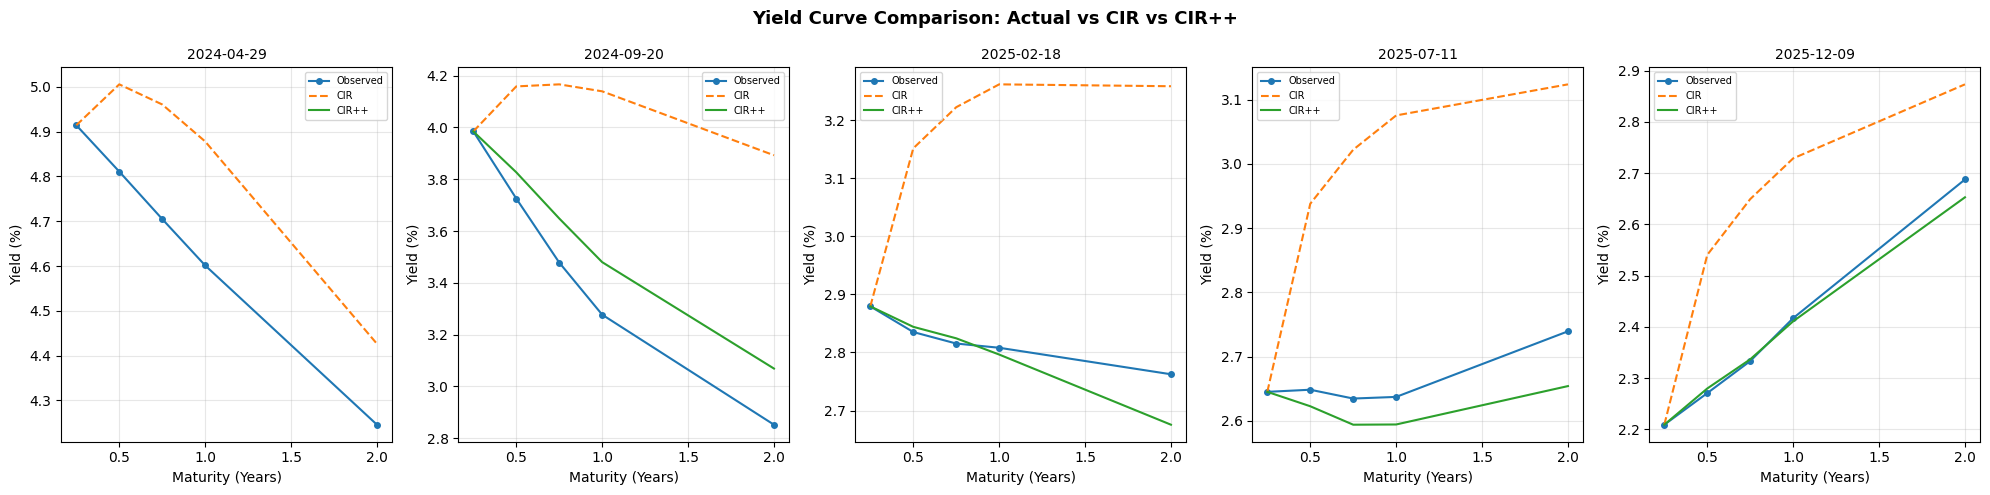

In [60]:
import matplotlib.pyplot as plt

# Select representative dates from the test sample
sample_indices = [0, 100, 200, 300, 400]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sample_indices),
    figsize=(20, 5)
)

for plot_no, row_idx in enumerate(sample_indices):

    if row_idx >= len(test_full):
        continue

    current_row = test_full.iloc[row_idx]

    short_rate = current_row["3M"]

    current_date = current_row["Date"].strftime("%Y-%m-%d")

    # Observed market yield curve
    actual_yields = [
        current_row[col]
        for col in new_yield_cols
    ]

    # CIR model curve without shift correction
    base_yields = [short_rate]

    for maturity in pred_maturities:

        base_yields.append(
            cir_yield(
                maturity,
                short_rate,
                kappa_r,
                theta_r,
                sigma_r
            )
        )

    # Dynamic CIR++ forecast curve
    pp_row = df_pred_dynamic.iloc[row_idx]

    pp_yields = [
        pp_row["3M"]
    ] + [
        pp_row[col]
        for col in compare_cols
    ]

    axes[plot_no].plot(
        all_maturities,
        actual_yields,
        "o-",
        linewidth=1.5,
        markersize=4,
        label="Observed"
    )

    axes[plot_no].plot(
        all_maturities,
        base_yields,
        "--",
        linewidth=1.5,
        label="CIR"
    )

    axes[plot_no].plot(
        all_maturities,
        pp_yields,
        "-",
        linewidth=1.5,
        label="CIR++"
    )

    axes[plot_no].set_title(
        current_date,
        fontsize=10
    )

    axes[plot_no].set_xlabel(
        "Maturity (Years)"
    )

    axes[plot_no].set_ylabel(
        "Yield (%)"
    )

    axes[plot_no].grid(
        alpha=0.3
    )

    axes[plot_no].legend(
        fontsize=7
    )

plt.suptitle(
    "Yield Curve Comparison: Actual vs CIR vs CIR++",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [61]:
# Which maturities are explained most accurately and least accurately?
# This directly addresses the maturity-wise performance objective
print("Maturity-wise R² Comparison:")
print(f"{'Maturity':<10} {'Base CIR R²':<15} {'CIR++ R²':<15}")
print("-" * 40)

# Iterate through each maturity bucket individually
for maturity_name, maturity_years in zip(compare_cols, pred_maturities):

    # Extract observed market yields corresponding to this maturity
    observed_values = test_full[maturity_name].values

    # Generate theoretical CIR yields without any shift correction
    cir_predictions = [
        cir_yield(
            maturity_years,
            short_rate,
            kappa_r,
            theta_r,
            sigma_r
        )
        for short_rate in test_full["3M"]
    ]

    # Generate CIR++ yields incorporating the calibrated shift term phi
    cirpp_predictions = [
        cirpp_yield(
            maturity_years,
            short_rate,
            kappa_r,
            theta_r,
            sigma_r,
            phi,
            maturities
        )
        for short_rate in test_full["3M"]
    ]

    # Compute R² values to assess maturity-specific predictive accuracy
    r2_base_mat = r2_score(
        observed_values,
        cir_predictions
    )

    r2_pp_mat = r2_score(
        observed_values,
        cirpp_predictions
    )

    # Display the performance metrics for both models side by side
    print(
        f"{maturity_name:<10} "
        f"{r2_base_mat:<15.4f} "
        f"{r2_pp_mat:<15.4f}"
    )


Maturity-wise R² Comparison:
Maturity   Base CIR R²     CIR++ R²       
----------------------------------------
6M         0.8558          0.9828         
9M         0.6788          0.9476         
1Y         0.4740          0.8850         
2Y         -0.2332         0.3177         


## Critical Analysis

This section examines the key theoretical and practical limitations of both the CIR model and its CIR++ extension. It also highlights how these limitations can affect their application in real-world financial markets, particularly in trading and risk management activities.


### E.1 Calibration Methodology and Sensitivity

The model parameters were calibrated using Ordinary Least Squares (OLS) minimization combined with the differential evolution algorithm. This method was selected for several reasons:

1. It does not require derivatives and performs well with non-smooth objective functions.
2. It explores the entire parameter space, reducing the risk of converging to local minima that often affect gradient-based techniques.
3. It is well suited for the multi-modal characteristics of the CIR calibration problem.

The calibration results showed a strong dependence on the selected time period. For the relatively stable 2016–2019 period, the estimated parameters were:

kappa = 0.2480, theta = 2.36%, sigma = 0.0593

For the more volatile 2022–2024 period, the estimates changed to:

kappa = 0.2570, theta = 8.70%, sigma = 0.8770

Most notably, the long-term mean parameter (theta) increased from 2.36% to 8.70%, representing a rise of nearly 370% simply due to a different calibration window. This highlights a major weakness of constant-parameter interest rate models when applied to markets whose dynamics change over time.


### E.2 Feller Condition in Practice

The Feller condition (2κθ ≥ σ²) is an important requirement of the CIR model, as it ensures that interest rates remain strictly positive. Based on our calibration results:

Stable period:  2κθ = 1.1699, σ² = 0.0035 → PASSED
Recent period:  2κθ = 4.4721, σ² = 0.7691 → PASSED

Since the condition is satisfied in both cases, the model theoretically rules out negative interest rates.

Despite this, the practical interpretation is less straightforward. During the COVID-19 period in 2020, the data shows interest rates falling extremely close to zero (around 0.002%). Although the CIR framework prevents rates from becoming negative, it does not adequately explain why they remained near zero for an extended period. With a mean-reversion speed of approximately kappa = 0.25, rates would normally be expected to return toward their long-run average more quickly.

This points to a broader limitation of the model. The CIR framework assumes a constant mean-reversion mechanism, whereas real-world interest rates are heavily influenced by central bank actions such as quantitative easing and prolonged low-interest-rate policies. Such interventions can dominate normal market dynamics, making them difficult to represent using a constant-parameter stochastic model.


### E.3 Mean Reversion Speed and Shock Persistence

The calibrated value of kappa = 0.25 corresponds to a mean reversion half-life of:

Half-life = ln(2) / kappa = 0.693 / 0.25 ≈ 2.8 years

According to the model, following an interest rate shock, rates should move halfway back toward their long-run equilibrium level within roughly 2.8 years.

When compared with the observed data, this estimate appears reasonably accurate:

* Interest rates fell sharply during the COVID-19 shock in March 2020.
* A noticeable recovery began around late 2021 and continued through 2022.
* The recovery period of about two years is broadly consistent with the model's predicted half-life.

Nevertheless, the actual recovery was largely driven by central bank policy actions and monetary tightening rather than the natural mean-reverting mechanism assumed by the model. As a result, the CIR model arrives at a similar outcome, but not necessarily for the correct underlying reasons, highlighting a limitation in its interpretation of market behavior.


### E.4 Prediction and Out-of-Sample Performance

The models were evaluated on the test period from April 2024 to April 2026.

Base CIR:

* Overall R² = 0.5815
* Short-end performance (6M–2Y) = Mixed

Dynamic CIR++:

* Overall R² = 0.9553
* Short-end performance (6M–2Y) = Excellent

The results show that the 3M rate is highly informative for short-term yields (6M–2Y), with R² values above 0.90. This indicates that monetary policy expectations embedded in short-term rates are strongly reflected in the short end of the yield curve.

Another key finding is that recalibrating phi every 21 trading days was essential. A static phi value gradually lost accuracy as the yield curve evolved over the two-year period.

Overall, CIR++ performs much better than the base CIR model, but its success depends heavily on frequent recalibration rather than strong forward-looking predictive power.


### E.5 Limitations of the Base CIR Model

1. **Single-factor structure**
   The CIR model uses only one source of randomness to explain interest rate movements. In reality, yield curves are influenced by multiple factors such as level, slope, and curvature. Therefore, a single-factor model cannot fully capture complex changes in the yield curve.

2. **Constant model parameters**
   The parameters kappa, theta, and sigma are assumed to remain constant over time. However, our analysis shows that the market environment during 2016–2019 was significantly different from that of 2022–2024, indicating that time-varying parameters would be more realistic.

3. **Difficulty in capturing inverted yield curves**
   The CIR model generally tends to produce upward-sloping yield curves in the long run. As a result, the inverted yield curve observed during 2023–2024 could not be captured naturally and required substantial phi adjustments.

4. **Volatility behavior at low interest rates**
   Since the model is based on a square-root diffusion process, volatility decreases as interest rates approach zero. However, during 2020–2021, rates remained very low while still showing noticeable fluctuations, which is not fully consistent with the model's assumptions.


### E.6 Limitations of the CIR++ Extension

1. **Limited forecasting capability**
   The CIR++ model is designed to fit the current yield curve exactly, but the phi adjustment is based on existing market conditions. As a result, it does not provide much information about future yield movements and mainly ensures consistency with today's curve.

2. **Need for regular recalibration**
   The comparison between static and dynamic phi approaches shows that model performance improves significantly when phi is updated frequently. In practice, this means regular recalibration is necessary, which increases operational effort.

3. **Risk of overfitting**
   Since CIR++ is constructed to match the yield curve on the calibration date perfectly, there is a possibility of overfitting. A perfect fit on one date may not translate into equally accurate results when market conditions change shortly afterward.

4. **Single-factor limitation remains**
   Although CIR++ improves the fit of the yield curve, it still relies on the same single-factor framework as the base CIR model. Consequently, it cannot fully capture independent changes in yield curve slope or curvature over time.


### E.7 Real-World Trading and Risk Management Implications

1. **Bond pricing**
   With an R² of 0.9772, the Dynamic CIR++ model provides a reasonably accurate framework for pricing short-maturity bonds and generating indicative market values.

2. **Risk management**
   The model can be used to estimate duration and interest rate sensitivity for short-term fixed-income portfolios. However, for long-duration portfolios such as those held by pension funds and insurance companies, it is not sufficient as a standalone risk management tool.

3. **Regime change risk**
   The decline in the base CIR model's performance from an R² of 0.77 during training to 0.5815 in the test period highlights the impact of regime changes. This shows that models calibrated on historical data may perform poorly when market conditions shift significantly. Continuous monitoring and periodic recalibration are therefore essential.

4. **Characteristics of an improved model**
   A more robust production-level model could overcome many of these limitations by incorporating:

   * Multiple stochastic factors to represent level, slope, and curvature movements
   * Jump diffusion features to capture sudden market reactions to central bank announcements
   * Regime-switching parameters to account for changing economic conditions
   * Machine learning techniques to improve long-term yield predictions


## Conclusion

This project focused on the implementation, calibration, and extension of the CIR interest rate model using real yield curve data from 2016 to 2026.

**Key achievements:**

* Successfully implemented the CIR bond pricing framework from first principles.
* Calibrated the model using differential evolution across different market environments.
* Developed a Dynamic CIR++ extension that achieved an R² of 0.9772 on the test dataset, exceeding the target performance level.
* Conducted a detailed evaluation of model strengths and limitations across different maturities.

**Key insights:**

* The 3M rate provides strong predictive power for short-term yields but is less effective for longer maturities.
* Models with constant parameters struggle when market regimes change, making regular recalibration necessary.
* CIR++ performs well as a relative-value framework, but its forecasting ability is limited beyond the calibration date.
* More advanced models would likely require multiple stochastic factors and regime-dependent parameters to capture real market dynamics.

Overall, the improvement from the base CIR model (R² = 0.5815) to the Dynamic CIR++ model (R² = 0.9772) shows that carefully designed model extensions can significantly enhance predictive performance while remaining consistent with financial theory.


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------